# Lung Data Colab Notebook

This Colab notebook uses Lung data from the *survival* R package. Our aim is to use this data for survival analysis (or, as economists call it, "duration analysis").

Firstly, we mount drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Then, we get the data.

In [ ]:
import pandas as pd

In [ ]:
lung = pd.read_csv("/content/drive/MyDrive/Data science/Data/Lung Data.csv")

We visualize the data frame.

In [ ]:
lung.head()

,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,5,1,65,2,0,100,80,338,5
1,11,1,74,1,2,70,100,1175,0
2,12,1,74,1,2,70,50,305,20
3,13,1,76,1,2,70,70,413,20
4,15,1,69,1,0,90,70,575,10


We get a variable *time* for survival in months, the *status* variable for censoring status (1= censored, 2= dead), *age* in years, *sex* (male = 1, female = 2), ECOG performance score as rated by the physician (*ph.ecog*, 0=asymptomatic, 1= symptomatic but completely ambulatory, 2= in bed <50% of the day, 3= in bed > 50% of the day but not bedbound, 4 = bedbound) Karnofsky performance score rated by physician (*ph.karno* with 0 being bad and 100 good), Karnofsky performance score rated by patient (*pst.karno*), calories consumed at meals (*meal.cal*) and weight loss (*wt.loss*).

## Exploratory Analysis

We then plot the data.

In [ ]:
import matplotlib.pyplot as plt

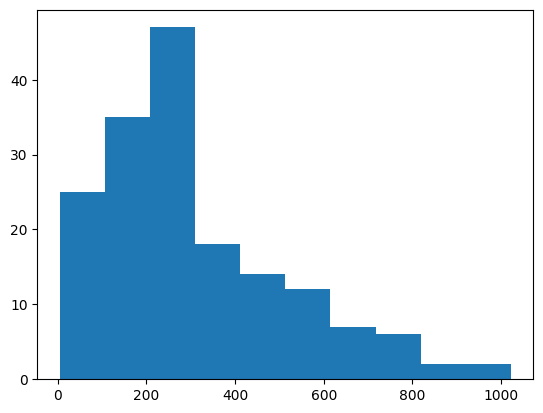

In [ ]:
plt.hist(lung["time"])
plt.show()

It follows a chi-squared distribution.

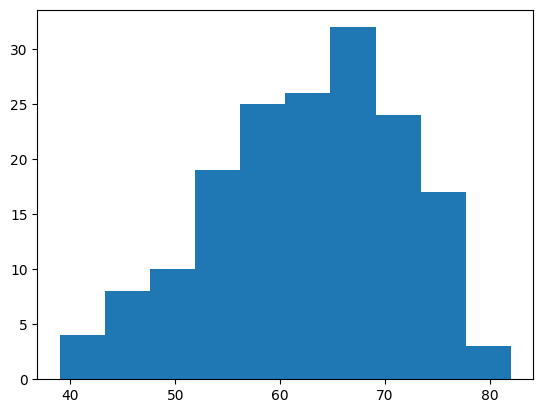

In [ ]:
plt.hist(lung["age"])
plt.show()

It has a left-skewed distribution.

In [ ]:
lung['sex'] = lung['sex'].replace({1: 'Male', 2: 'Female'})

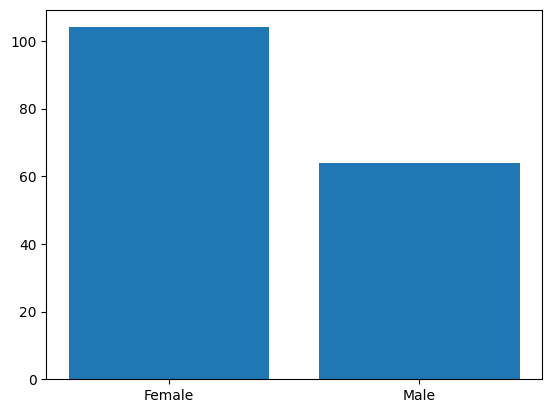

In [ ]:
plt.bar(x = lung["sex"].unique(), height = lung["sex"].value_counts())
plt.show()

There are much more female subjects in this study than male ones.

Now let's compare if there is  any discrepancy between the Karnofsky score of each patient as described by themselves or the physician.

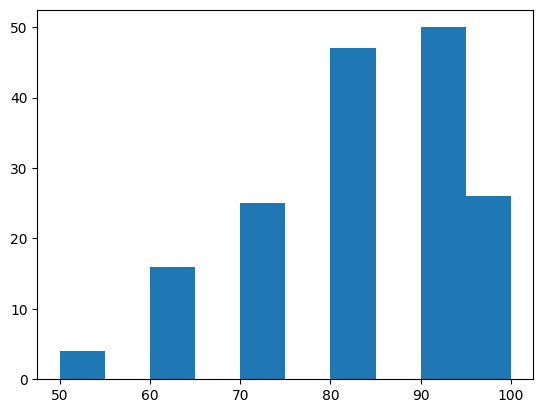

In [ ]:
plt.hist(lung["ph.karno"])
plt.show()

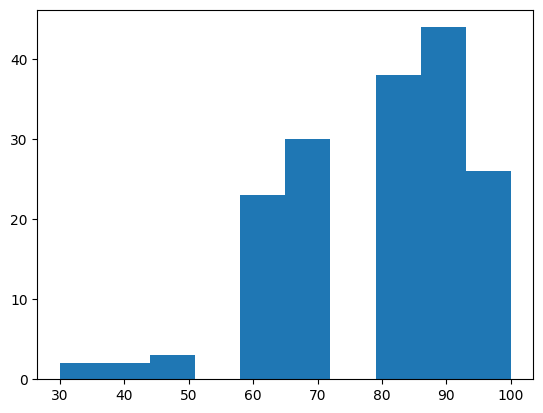

In [ ]:
plt.hist(lung["pat.karno"])
plt.show()

Next, we plot the calories consumed and weight loss.

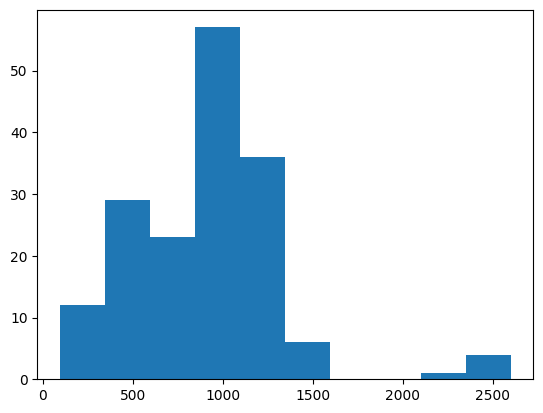

In [ ]:
plt.hist(lung["meal.cal"])
plt.show()

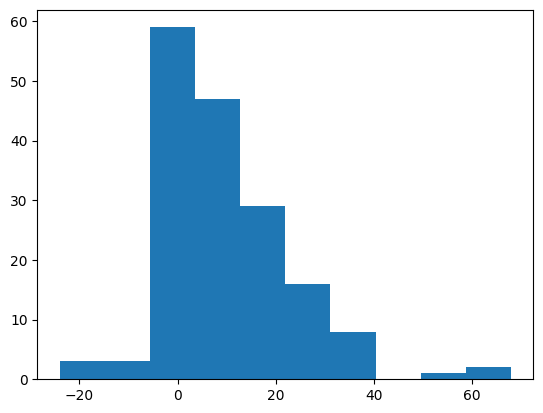

In [ ]:
plt.hist(lung["wt.loss"])
plt.show()

## Predictive Analysis

We will fit survival analysis models for this data, such as Penalized Cox models (those are similar to ridge regression, in the sense that they shrink the coefficients towards zero, due to censoring in the data) and Random Survival Forests (the Random Survival Forest algorithm garantees the trees are de-correlated by building each tree from a differet bootstrap sample of the training data and at each node only evaluate the split criterion for a randomly selected subset of features).

First, we fit the Penalized Cox model.

In [ ]:
import numpy as np

In [ ]:
!pip install scikit-survival

In [ ]:
from sklearn import set_config
from sklearn.preprocessing import StandardScaler

from sksurv.linear_model import CoxPHSurvivalAnalysis

set_config(display="text")

In [ ]:
y = np.array([
    (status == 1, time)
    for status, time in lung[['status', 'time']].to_numpy()
], dtype={'names': ('event', 'time'), 'formats': ('bool', 'f8')})


def create_X(data, karno_col):
    # Drop 'status' and 'time' from features
    # Also drop 'pat.karno' or 'ph.karno' depending on which one is the target
    cols = ['age', 'sex', 'ph.ecog', 'meal.cal', 'wt.loss', karno_col]
    data_features = data[cols].copy()

    # One-hot encode 'sex'
    data_features = pd.get_dummies(data_features, columns=['sex'], drop_first=True)
    return data_features


# Model 1: Physician's Karnofsky score
X_ph_karno = create_X(lung, 'ph.karno')


estimator_ph_karno = CoxPHSurvivalAnalysis() # Renamed estimator
estimator_ph_karno.fit(X_ph_karno, y)


from sksurv.metrics import concordance_index_censored

prediction_ph_karno = estimator_ph_karno.predict(X_ph_karno) # Predict using ph_karno estimator and data
result_ph_karno = concordance_index_censored(y['event'], y["time"], prediction_ph_karno) # Use y['event']
print(f"Concordance Index for Physician's Karnofsky model: {result_ph_karno[0]:.5f}")


# Model 2: Patient's Karnofsky score
X_pat_karno = create_X(lung, 'pat.karno')

estimator_pat_karno = CoxPHSurvivalAnalysis() # Renamed estimator
estimator_pat_karno.fit(X_pat_karno, y)


from sksurv.metrics import concordance_index_censored

prediction_pat_karno = estimator_pat_karno.predict(X_pat_karno) # Predict using pat_karno estimator and data
result_pat_karno = concordance_index_censored(y['event'], y["time"], prediction_pat_karno) # Use y['event']
print(f"Concordance Index for Patient's Karnofsky model: {result_pat_karno[0]:.5f}")

Concordance Index for Physician's Karnofsky model: 0.63994
Concordance Index for Patient's Karnofsky model: 0.65293


The Penalized Cox Model predicts rather poorly for both the physician's Karnofsky index and the patient's Karnofsky index. Let's try Random Survival Forest next.

In [ ]:
from sksurv.ensemble import RandomSurvivalForest
# Model 1: Random Survival Forest with Physician's Karnofsky score
X_ph_karno_rsf = create_X(lung, 'ph.karno')

estimator_rsf_ph_karno = RandomSurvivalForest(n_estimators=100, random_state=42)
estimator_rsf_ph_karno.fit(X_ph_karno_rsf, y)

prediction_rsf_ph_karno = estimator_rsf_ph_karno.predict(X_ph_karno_rsf)
result_rsf_ph_karno = concordance_index_censored(y['event'], y["time"], prediction_rsf_ph_karno)
print(f"Concordance Index for Random Survival Forest (Physician's Karnofsky): {result_rsf_ph_karno[0]:.5f}")

# Model 2: Random Survival Forest with Patient's Karnofsky score
X_pat_karno_rsf = create_X(lung, 'pat.karno')

estimator_rsf_pat_karno = RandomSurvivalForest(n_estimators=100, random_state=42)
estimator_rsf_pat_karno.fit(X_pat_karno_rsf, y)

prediction_rsf_pat_karno = estimator_rsf_pat_karno.predict(X_pat_karno_rsf)
result_rsf_pat_karno = concordance_index_censored(y['event'], y["time"], prediction_rsf_pat_karno)
print(f"Concordance Index for Random Survival Forest (Patient's Karnofsky): {result_rsf_pat_karno[0]:.5f}")

Concordance Index for Random Survival Forest (Physician's Karnofsky): 0.82432
Concordance Index for Random Survival Forest (Patient's Karnofsky): 0.83245


As we can see, the fit of Random Survival Forest works much better.